In [15]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 
from sklearn.preprocessing import StandardScaler

In [16]:
data = pd.read_csv('Crop_Recommendation.csv')
data.head()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice


In [17]:
pd.unique(data['Crop'])

array(['Rice', 'Maize', 'ChickPea', 'KidneyBeans', 'PigeonPeas',
       'MothBeans', 'MungBean', 'Blackgram', 'Lentil', 'Pomegranate',
       'Banana', 'Mango', 'Grapes', 'Watermelon', 'Muskmelon', 'Apple',
       'Orange', 'Papaya', 'Coconut', 'Cotton', 'Jute', 'Coffee'],
      dtype=object)

In [ ]:
pd.value_counts(data['Crop'])



/var/folders/74/1sy6q_b53cx2cyz0sb1vtw8m0000gn/T/ipykernel_8533/1919446347.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(data['Crop'])


Crop
Rice           100
Maize          100
Jute           100
Cotton         100
Coconut        100
Papaya         100
Orange         100
Apple          100
Muskmelon      100
Watermelon     100
Grapes         100
Mango          100
Banana         100
Pomegranate    100
Lentil         100
Blackgram      100
MungBean       100
MothBeans      100
PigeonPeas     100
KidneyBeans    100
ChickPea       100
Coffee         100
Name: count, dtype: int64

In [20]:
X,Y = data.iloc[:,:-1], data['Crop']

<Axes: >

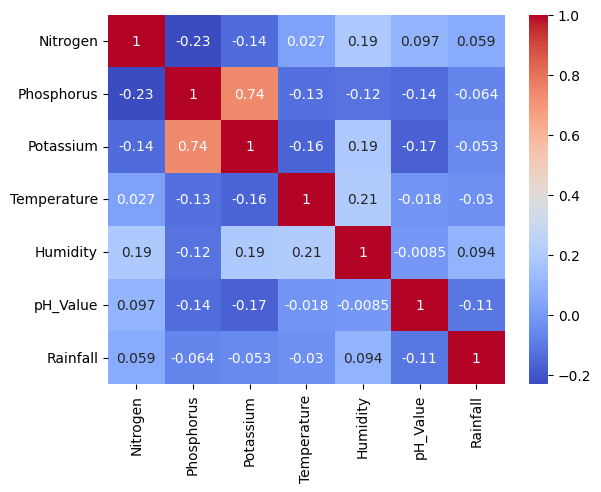

In [21]:
X_corr = X.corr()
sns.heatmap(X_corr, annot = True, cmap='coolwarm')

In [22]:
X = X.drop(columns=["Phosphorus"])
X

,Nitrogen,Potassium,Temperature,Humidity,pH_Value,Rainfall
0,90,43,20.879744,82.002744,6.502985,202.935536
1,85,41,21.770462,80.319644,7.038096,226.655537
2,60,44,23.004459,82.320763,7.840207,263.964248
3,74,40,26.491096,80.158363,6.980401,242.864034
4,78,42,20.130175,81.604873,7.628473,262.717340
...,...,...,...,...,...,...
2195,107,32,26.774637,66.413269,6.780064,177.774507
2196,99,27,27.417112,56.636362,6.086922,127.924610
2197,118,30,24.131797,67.225123,6.362608,173.322839
2198,117,34,26.272418,52.127394,6.758793,127.175293


In [23]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X.values)
X_scaled = pd.DataFrame(scaled_data, columns=X.columns)
X_scaled.head()

,Nitrogen,Potassium,Temperature,Humidity,pH_Value,Rainfall
0,1.068797,-0.101688,-0.935587,0.472666,0.043302,1.810361
1,0.933329,-0.141185,-0.759646,0.397051,0.734873,2.242058
2,0.255986,-0.081939,-0.515898,0.486954,1.771510,2.921066
3,0.635298,-0.160933,0.172807,0.389805,0.660308,2.537048
4,0.743673,-0.121436,-1.083647,0.454792,1.497868,2.898373


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import  accuracy_score, f1_score
from sklearn.model_selection import GridSearchCV


X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size= 0.2, random_state=42)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4] 
}

clf = DecisionTreeClassifier()
grid_searchcv = GridSearchCV(estimator=clf, param_grid = param_grid, cv=5, scoring='accuracy')
grid_searchcv.fit(X_train, y_train)

results = pd.DataFrame(grid_searchcv.cv_results_)
results.head()


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.005685,0.000976,0.001195,0.000490,gini,None,1,2,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.971591,0.965909,0.974432,0.985795,0.982955,0.976136,0.007321,5
1,0.004250,0.000168,0.000760,0.000214,gini,None,1,5,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.971591,0.965909,0.977273,0.982955,0.982955,0.976136,0.006626,5
2,0.003963,0.000106,0.000603,0.000057,gini,None,1,10,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.965909,0.977273,0.971591,0.982955,0.985795,0.976705,0.007276,4
3,0.003941,0.000129,0.000580,0.000054,gini,None,2,2,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.963068,0.977273,0.974432,0.982955,0.982955,0.976136,0.007321,5
4,0.003898,0.000103,0.000567,0.000012,gini,None,2,5,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.965909,0.977273,0.977273,0.982955,0.982955,0.977273,0.006224,1


In [25]:
best_params = grid_searchcv.best_params_
print("Best Hyperparameters:", best_params)
best_clf = DecisionTreeClassifier(**best_params)
best_clf.fit(X_train, y_train)
y_pred = best_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
print("Accuracy:", accuracy)
print("F1 Score:", f1)

Best Hyperparameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5}
Accuracy: 0.9613636363636363
F1 Score: 0.9612479422434043


In [27]:

# Now we will use XGBOOST Classifier and see if we can get better results.
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

xgb_clf = XGBClassifier()
label_encoder  = LabelEncoder()
y_encoded = label_encoder.fit_transform(Y)
X_train, X_test, y_train_XG, y_test_XG = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)
param_grid_xgb = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
}
grid_searchcv_xgb = GridSearchCV(estimator = xgb_clf, param_grid = param_grid_xgb, cv=5, scoring='accuracy')
grid_searchcv_xgb.fit(X_train, y_train_XG)



GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [32]:
results_xgb = pd.DataFrame(grid_searchcv_xgb.cv_results_)
results_xgb.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.270202,0.064244,0.002047,0.000265,0.01,3,100,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",0.963068,0.971591,0.960227,0.963068,0.982955,0.968182,0.008312,27
1,2.817646,0.083948,0.003059,0.000261,0.01,3,200,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",0.963068,0.974432,0.974432,0.980114,0.991477,0.976705,0.009232,26
2,4.291087,0.127853,0.003675,0.000273,0.01,3,300,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",0.968750,0.974432,0.974432,0.988636,0.991477,0.979545,0.008875,22
3,1.855145,0.042720,0.002393,0.000064,0.01,5,100,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est...",0.968750,0.982955,0.960227,0.988636,0.991477,0.978409,0.011999,25
4,3.561696,0.101953,0.002837,0.000082,0.01,5,200,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est...",0.965909,0.982955,0.968750,0.991477,0.991477,0.980114,0.010929,21


In [35]:
best_params_xgb = grid_searchcv_xgb.best_params_
print("Best Hyperparameters for XGBoost:", best_params)
best_xgb_clf = XGBClassifier(**best_params)
best_xgb_clf.fit(X_train, y_train_XG)
y_pred_xgb = best_xgb_clf.predict(X_test)
accuracy_xgb = accuracy_score(y_test_XG, y_pred_xgb)
print("Accuracy of XGBoost:", accuracy_xgb)

Best Hyperparameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Accuracy of XGBoost: 0.9886363636363636


In [33]:
# Now We will use Random Forest Classifier and see if we can get betterresults.

from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier()
X_train, X_test, y_train_RF, y_test_RF = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_searchcv_rf = GridSearchCV(estimator=rf_clf, param_grid=param_grid_rf, cv=5, scoring='accuracy')
grid_searchcv_rf.fit(X_train, y_train_RF)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [36]:
results_rf = pd.DataFrame(grid_searchcv_rf.cv_results_)
results_rf.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.108769,0.002323,0.004251,0.000046,None,1,2,100,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.982955,0.991477,0.985795,0.997159,0.997159,0.990909,0.005794,6
1,0.219283,0.001992,0.007750,0.000186,None,1,2,200,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.985795,0.991477,0.982955,0.997159,0.994318,0.990341,0.005269,19
2,0.324588,0.000899,0.010988,0.000143,None,1,2,300,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.982955,0.991477,0.982955,0.997159,0.994318,0.989773,0.005850,35
3,0.109198,0.001096,0.004096,0.000082,None,1,5,100,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.982955,0.991477,0.988636,0.997159,0.994318,0.990909,0.004888,6
4,0.219536,0.000988,0.007697,0.000202,None,1,5,200,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.980114,0.991477,0.985795,0.997159,0.994318,0.989773,0.006120,23


In [39]:
best_params_rf = grid_searchcv_rf.best_params_
print("Best Hyperparameters for Random Forest:", best_params_rf)
best_rf_clf = RandomForestClassifier(**best_params_rf)
best_rf_clf.fit(X_train, y_train_RF)
y_pred_rf = best_rf_clf.predict(X_test)
accuracy_rf = accuracy_score(y_test_RF, y_pred_rf)
print("Accuracy of Random Forest:", accuracy_rf)

Best Hyperparameters for Random Forest: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Accuracy of Random Forest: 0.9886363636363636


In [43]:

f1_xgb = f1_score(y_test_XG, y_pred_xgb, average='weighted')
f1_rf = f1_score(y_test_RF, y_pred_rf, average='weighted')

results_summary = pd.DataFrame({
    'Classifier': ['Decision Tree', 'XGBoost', 'Random Forest'],
    'Best Hyperparameters': [str(best_params), str(best_params_xgb), str(best_params_rf)],
    'Accuracy': [accuracy, accuracy_xgb, accuracy_rf],
    'F1 Score (Weighted)': [f1, f1_xgb, f1_rf]
})

results_summary


,Classifier,Best Hyperparameters,Accuracy,F1 Score (Weighted)
0,Decision Tree,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.961364,0.961248
1,XGBoost,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.988636,0.988626
2,Random Forest,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.986364,0.986326
